# MetaLore — Quick Demo

In [1]:
import sys
sys.path.insert(0, '.')

import matplotlib.pyplot as plt
from IPython import display as ipd

from metalore.scenarios import SingleCellEnv
from metalore.config import default_config

print('MetaLore imported successfully!')

MetaLore imported successfully!


## Create & Reset Environment

In [2]:
env = SingleCellEnv(config=default_config())
obs, info = env.reset()

print(f'Base Stations : {env.num_bs}')
print(f'UEs           : {env.num_ues}')
print(f'Sensors       : {env.num_sensors}')
print(f'Area          : {env.width} x {env.height} m')
print(f'Max Steps     : {env.EP_MAX_TIME}')
print(f'Action Space  : {env.action_space}')
print(f'Obs Space     : {env.observation_space}')
print(f'Initial obs   : {obs}')

Base Stations : 1
UEs           : 15
Sensors       : 45
Area          : 200.0 x 200.0 m
Max Steps     : 100
Action Space  : Box(0.0, 1.0, (2,), float32)
Obs Space     : Box(0.0, 10000.0, (2,), float32)
Initial obs   : [0. 0.]


## Run Episode with Rendering

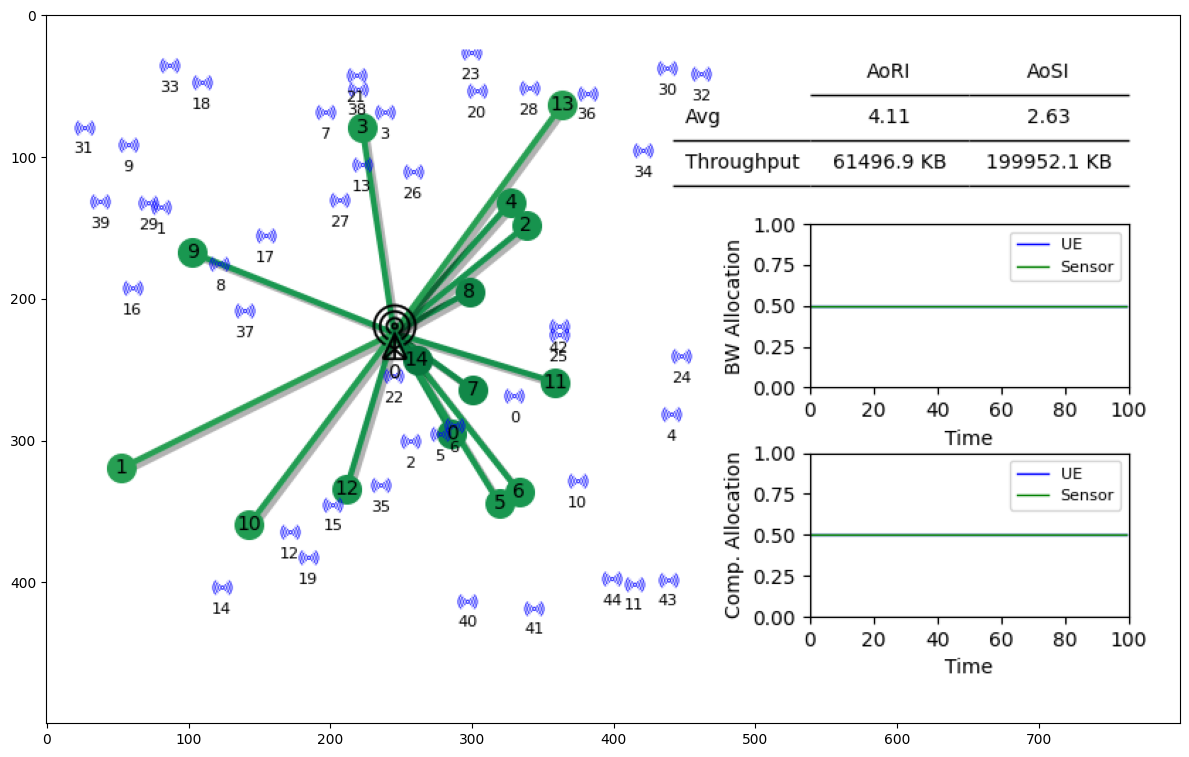

Episode ended at step 100

Steps completed : 100
Total reward    : 7339.0823


In [3]:
# Run a full episode with random actions
N_STEPS =  100

rewards = []
for step in range(N_STEPS):
    #action = env.action_space.sample()   # random policy
    action = [0.5, 0.5]                   # fixed equal-split policy
    obs, reward, terminated, truncated, info = env.step(action)
    rewards.append(reward)

    # Animate during simulation
    ipd.clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(env.render())
    plt.tight_layout()
    plt.show()
    plt.close()

    if terminated or truncated:
        print(f"Episode ended at step {step+1}")
        break

print()
print(f"Steps completed : {len(rewards)}")
print(f"Total reward    : {sum(rewards):.4f}")

## Job Log (completed jobs)

In [4]:
import pandas as pd
from IPython.display import display

job_df = env.job_tracker.to_dataframe()
print(f'Completed jobs: {len(job_df)}')
display(job_df)

Completed jobs: 4983


,job_id,entity_id,entity_type,data_size,compute_size,generated_at,tx_start_at,tx_end_at,proc_start_at,proc_end_at,tx_queue_wait,tx_duration,proc_queue_wait,proc_duration,nearest_sensor_id,sensor_snapshot_at,aoi,aori,aosi
0,13,0,SENSOR,399929.0,24999964.0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,NaN
1,14,1,SENSOR,400563.0,25003521.0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,NaN
2,15,2,SENSOR,401197.0,25003428.0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,NaN
3,16,3,SENSOR,401907.0,25012496.0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,NaN
4,17,4,SENSOR,400660.0,24995891.0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4978,4935,34,SENSOR,400117.0,24999852.0,88,88,88,99,99,0,0,11,0,NaN,NaN,NaN,11,NaN
4979,4936,35,SENSOR,400176.0,25007468.0,88,88,88,99,99,0,0,11,0,NaN,NaN,NaN,11,NaN
4980,4937,36,SENSOR,399030.0,24991561.0,88,88,88,99,99,0,0,11,0,NaN,NaN,NaN,11,NaN
4981,4938,37,SENSOR,400497.0,25001131.0,88,88,88,99,99,0,0,11,0,NaN,NaN,NaN,11,NaN


## AoI Summary (UE jobs only)

In [5]:
ue_df = job_df[job_df['entity_type'] == 'UE']

for col, label in [('aori', 'AoRI'), ('aosi', 'AoSI'), ('aoi', 'AoI')]:
    s = ue_df[col].dropna()
    if not s.empty:
        print(f'{label:5s}  mean={s.mean():.2f}  max={s.max():.0f}  min={s.min():.0f}')

AoRI   mean=4.11  max=7  min=1
AoSI   mean=2.63  max=6  min=0
AoI    mean=6.66  max=12  min=1
